# COE 311K – GDP Midterm Project 
## March 31, 2026 | Mary Grayson Horton (mh63289)
---
## Introduction
This project applies three curve-fitting and interpolation techniques to a real-world economic dataset. 

Our data consists of 20 selected quarters spanning 2010 Q1 through 2023 Q4, sourced from the U.S. Bureau of Economic Analysis (BEA). Each quarter has a corresponding U.S. Quarterly GDP Growth Rate (seasonally adjusted annual rate, SAAR). Most rates are < 10, except for the values in 2020 Q2 (−28.1%) and Q3 (+33.8%) that reflect the COVID-19 pandemic shock and recovery. These outliers will come up in our curve fitting & interpolation analysis. First, we will run a cubic spline interpolation, a function that passes exactly through the full dataset; second, we will fit a degree-4 polynomial to the data using least squares; and third, we will fit a least squares linear model to the data, excluding the COVID quarters. After we apply the methods, we will assess which method performed best for each purpose and the limitations of each approach. In turn, we can learn more about long-run U.S. GDP trends.

**Three Techniques Used:**
1. **Cubic Spline Interpolation** – constructs a function that passes exactly through the full dataset
2. **Polynomial Fitting** – fits the degree-4 polynomial to the data using least squares 
3. **Least Squares** – fits a least squares linear model to the data, exclusing the COVID quarters

## Imports and Data

In [63]:
# IMPORT STATEMENTS
import numpy as np
import matplotlib.pyplot as plt


labels = [
    '2010 Q1','2011 Q1','2012 Q1','2013 Q1',
    '2014 Q1','2014 Q3','2015 Q2',
    '2016 Q1','2016 Q3','2016 Q4',
    '2017 Q1','2018 Q1','2019 Q1',
    '2020 Q1','2020 Q2','2020 Q3',
    '2021 Q1','2022 Q1','2023 Q2','2023 Q4'
]

# QUARTERS (used consecutive integer quarter indices as x-values, but also opted to account for gaps in time)
x = np.array([
     1,  5,  9,  13,
     17,  19,  22,
     25,  27,  28,
     29,  33,  37,
     41, 42, 43,
     45, 49, 54, 56
])

# GDP GROWTH (%)
y = np.array([
     1.7,  0.1,  2.3,  2.7,
     1.7,  5.0,  3.0,
     1.5,  3.5,  1.8,
     1.3,  2.5,  3.1,
    -5.1, -28.1, 33.8,
     6.3, -1.6,  2.4,  3.3
])

all_quarters = []
for year in range(2010, 2024):
    for q in range(1, 5):
        all_quarters.append(f'{year} Q{q}')

## Part A – Cubic Spline Interpolation 
**Part 1.** Here, we have constructed a natural cublic spline interpolant through the full dataset (all provided quarters). See the custom methods below. 

To solve, we use the following equations: 

$S_i(t) = a_i + b_i(t-x_i) + c_i(t-x_i)^2 + d_i(t-x_i)^3$, $S_i'(x_i)$, and $S_i''(x_i)$

Also, $M_0=M_{19}=0$.

We have a total of 4(n−1) unknowns, and so we need 4(n−1) independent equations to find all the coefficients (1). In our case, n=20, so (n−1)= 19. Therefore, we have 76 unknowns.

There are a few continuity conditions at each interior knot. The spline value is equal from the left and right, the first derivative is equal from the left and right piece, and the second derivative is equal from the left and right piece. Also, a natural spline is bounded by the assumption that the second derivatives are zero at the endpoints (aka. the curve is a “straight line” at the end points). 

(1) Qingkai Kong, Timmy Siauw, Alexandre M. Bayen, Python Programming And Numerical Methods: A Guide For Engineers And Scientists, https://pythonnumericalmethods.berkeley.edu/notebooks/Index.html

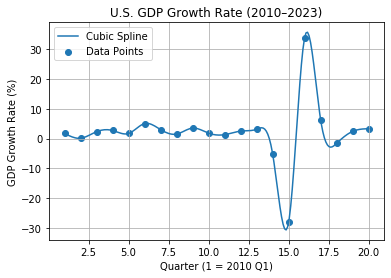

In [77]:
# Thomas algorithm function
def thomas_algorithm( a, b, c, d ):
    """
    Solve the tridiagonal system using the Thomas algorithm.
    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    Returns: solution vector x of length n
    """
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]

    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x

# Algorithm for setting up tridiagonal matrix 
def setup_tridiagonal_matrix( x, y ):
    h = np.diff(x)  # step sizes
    A = []
    B = []
    C = []
    D = []
    for i in range( 1, len(x) - 1 ):
        left_slope = (y[i] - y[i-1]) / h[i-1]
        right_slope = (y[i+1] - y[i]) / h[i]
        A.append(h[i-1])
        B.append(2 * (h[i-1] + h[i]))
        C.append(h[i])
        D.append(6* (right_slope - left_slope))
    return A, B, C, D 
        
# Algorithm for solving spline at a point
def evaluate_spline(x, y, m, x_eval):
    # Find interval
    for i in range(len(x) - 1):
        if(x[i] <= x_eval <= x[i+1]):
            xL, xU = x[i], x[i+1]
            yL, yU = y[i], y[i+1]
            mL, mU = m[i], m[i+1]
            break
    h = xU - xL
    # Cubic spline formula
    term1 = mL * (xU - x_eval)**3 / (6 * h)
    term2 = mU * (x_eval - xL)**3 / (6 * h)
    term3 = (yL - mL * h**2 / 6) * (xU - x_eval) / h
    term4 = (yU - mU * h**2 / 6) * (x_eval - xL) / h
    total = term1 + term2 + term3 + term4
    return total
            
# Setup tridiagonal system 
a, b, c, d = setup_tridiagonal_matrix(x, y)

# Evaluate spline over many points 
m_internal = thomas_algorithm(a, b, c, d)
m = np.concatenate(([0], m_internal, [0]))
x_eval = np.linspace(min(x), max(x), 200)
y_eval = []
for xi in x_eval:
    y_eval.append(evaluate_spline(x, y, m, xi))

# Plot the results
plt.scatter(x, y, marker='o', label='Data Points')
plt.plot(x_eval, y_eval, label='Cubic Spline')
plt.title('U.S. GDP Growth Rate (2010–2023)')
plt.xlabel('Quarter (1 = 2010 Q1)')
plt.ylabel('GDP Growth Rate (%)')
plt.grid(True)
plt.legend()
plt.show()

**Part 2. Evaluating the full dataset** 
The full quarterly dataset has 55 points (2010 Q1 through 2023 Q4). Using the spline from the subset above, we can evaluate it at every quarter in the full range and plot the result. 

The interpolant is visually smooth throughout most of the dataset. For the 2010–2019 range, there are no abrupt jumps. However, near the COVID quarters, the spline must pass exactly through −28.1% and +33.8% within a tight range, causing it to steeply swing to hit the point. Now, that region produces estimates for surrounding quarters that are far outside any realistic GDP range. The math is technically correct, the curve remains continuous as intended, but the actual result is economics are meaningless near the pandemic shock.

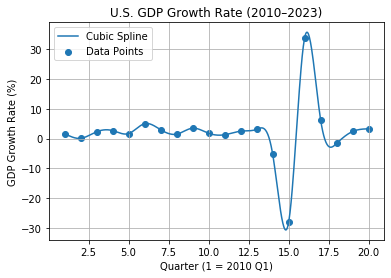

In [78]:
# Evaluation at all 55 quarters
x_full = np.linspace(min(x), max(x), 550)

# Re-evaluate the spline for the extended data 
y_full = [] 
for xi in x_full:
    y_full.append(evaluate_spline(x, y, m, float(xi)))

# Plot the results
plt.scatter(x, y, marker='o', label='Data Points')
plt.plot(x_full, y_full, label='Cubic Spline')
plt.title('U.S. GDP Growth Rate (2010–2023)')
plt.xlabel('Quarter (1 = 2010 Q1)')
plt.ylabel('GDP Growth Rate (%)')
plt.grid(True)
plt.legend()
plt.show()

**Part 3. Discussion of extraneous COVID values** 

The spline must pass exactly through the 2020 Q2 value (-28.1%). When a curve is forced through extreme values, it overshoots in the neighboring regions. This is the Runge Phenomenon, which we can see in the plot above. The spline swings outside reasonable GDP values near the COVID quarters just to satisfy the exact −28.1%. There is a key trade-off we must consider. Exact interpolation guarantees zero error at every data point, but one extreme outlier corrupts the estimates for all surrounding quarters. 

A smoothing spline would allow the curve to pass near −28.1% instead of exactly through it, reducing the wild swings at the cost of a small error at that point. A weighted least squares would assign a very small weight to the COVID quarters, so they barely influence the fitted curve at all.

Both might be preferable here because the COVID years are a known shock, and forcing the curve through it produces interpolated values for surrounding quarters that do not always fit the true economics. Accepting a small error at the outlier is worth more stability everywhere else. 

## Part B – Polynomial & Least Squares Comparison  
**Part 1.** Here, we have fit a degree-4 polynomial to the data using least squares and plotted it alongside the cubic spline. 

The cubic spline better reproduces specific data points. Visually, we can see that it passes through every one exactly. That said, the degree-4 polynomial better captures the overall trend. It smooths over the COVID outliers instead of overarching to thread through them. 

The main trade-off here is interpolation vs. approximation. The spline prioritizes exactness at known points, whereas the degree-4 polynomial prioritizes a reasonable curve across the whole range. With extreme outliers like the COVID quarters, the polynomial's approximation might be more useful in understanding the broader economic trend. In the graph, we can see a long-term trend of a growth rate between -5% and 5%. 

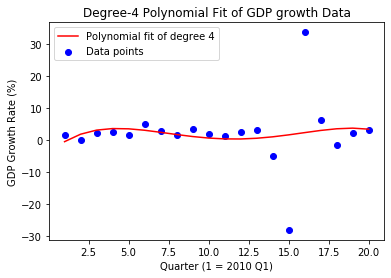

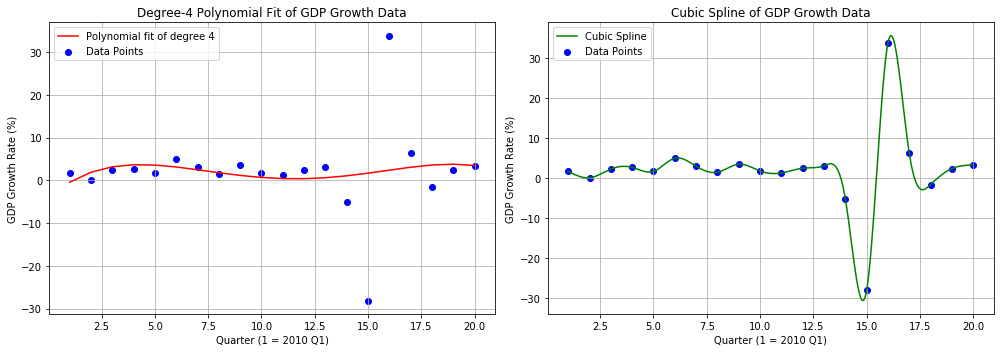

In [75]:
# Reassigning the data here 
x = x_data
y = y_data

# Create Vandermonde matrix
degree = 4
V = np.vander(x, N=degree+1, increasing=True)

# Normal equations
VT_V = np.dot(V.T, V)
VT_y = np.dot(V.T, y)

# Solve for coefficients
coefficients = np.linalg.solve(VT_V, VT_y)

# Evaluate
y_pred = V @ coefficients

# Plotting the results
plt.scatter(x, y, color='blue', label='Data points') # Original data points
plt.plot(x, y_pred, color='red', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.title('Degree-4 Polynomial Fit of GDP growth Data')
plt.xlabel('Quarter (1 = 2010 Q1)')
plt.ylabel('GDP Growth Rate (%)')
plt.legend()
plt.show()

# Subplot setup below 
a_tri, b_tri, c_tri, d_tri = setup_tridiagonal_matrix(x, y)
m_internal = thomas_algorithm(a_tri, b_tri, c_tri, d_tri)
M = np.concatenate(([0], m_internal, [0]))

x_full = np.linspace(float(x[0]), float(x[-1]), 1000)
y_full = [evaluate_spline(x, y, M, float(xi)) for xi in x_full]

plt.figure(figsize=(14, 5))

# Left: Polynomial fit
plt.subplot(1, 2, 1)
plt.scatter(x, y, color='blue', label='Data Points')
plt.plot(x, y_pred, color='red', label=f'Polynomial fit of degree {degree}')
plt.title('Degree-4 Polynomial Fit of GDP Growth Data')
plt.xlabel('Quarter (1 = 2010 Q1)')
plt.ylabel('GDP Growth Rate (%)')
plt.legend()
plt.grid(True)

# Right: Cubic spline
plt.subplot(1, 2, 2)
plt.scatter(x, y, color='blue', label='Data Points')
plt.plot(x_full, y_full, color='green', label='Cubic Spline')
plt.title('Cubic Spline of GDP Growth Data')
plt.xlabel('Quarter (1 = 2010 Q1)')
plt.ylabel('GDP Growth Rate (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**Part 2.** Now, we will fit a least squares linear model to the data including and excluding the COVID quarters (2020 Q1 - 2021 Q1).

Equation: y = 0.0457x + 1.5800

Slope: 0.0457
Intercept: 1.5800

Largest Residual:
X = 16.00, Residual = 31.4886

Smallest Residual:
X = 19.00, Residual = -0.0486


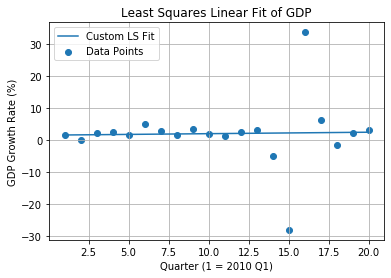

Equation: y = -0.0173x + 2.3041

Slope: -0.0173
Intercept: 2.3041

Largest Residual:
X = 18.00, Residual = -3.5921

Smallest Residual:
X = 3.00, Residual = 0.0479


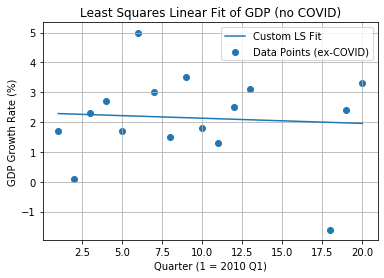

In [47]:
# custom LS method
def my_least_squares(x, y):
    n = len(x)
    sum_x = np.sum(x)
    sum_y = np.sum(y)
    sum_xy = np.sum(x * y)
    sum_x2 = np.sum(x ** 2)
    m = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x**2)
    b = (sum_y - m * sum_x) / n
    return m, b

# Data with COVID quarters 
X = x_data
Y = y_data
X = np.sort(X)

m, b = my_least_squares(X, Y)

# Evaluate and residuals
Y_pred = m * X + b
residuals = Y - Y_pred
max_residual_index = np.argmax(np.abs(residuals))
min_residual_index = np.argmin(np.abs(residuals))

print(f"Equation: y = {m:.4f}x + {b:.4f}")
print(f"\nSlope: {m:.4f}")
print(f"Intercept: {b:.4f}")
print("\nLargest Residual:")
print(f"X = {X[max_residual_index]:.2f}, Residual = {residuals[max_residual_index]:.4f}")
print("\nSmallest Residual:")
print(f"X = {X[min_residual_index]:.2f}, Residual = {residuals[min_residual_index]:.4f}")

# Plot
x_line = np.linspace(min(X), max(X), 100)
y_line = m * x_line + b
plt.scatter(X, Y, label="Data Points")
plt.plot(x_line, y_line, label="Custom LS Fit")
plt.xlabel("Quarter (1 = 2010 Q1)")
plt.ylabel("GDP Growth Rate (%)")
plt.title("Least Squares Linear Fit of GDP")
plt.legend()
plt.grid(True)
plt.show()

# Exclude COVID quarters 
# Asked Claude how to best remove the COVID quarters - suggested mask method
covid_set = {14.0, 15.0, 16.0, 17.0}
mask = np.array([xi not in covid_set for xi in x_data])
X = x_data[mask]
Y = y_data[mask]
X = np.sort(X)

m, b = my_least_squares(X, Y)

# Evaluate and residuals
Y_pred = m * X + b
residuals = Y - Y_pred
max_residual_index = np.argmax(np.abs(residuals))
min_residual_index = np.argmin(np.abs(residuals))

print(f"Equation: y = {m:.4f}x + {b:.4f}")
print(f"\nSlope: {m:.4f}")
print(f"Intercept: {b:.4f}")
print("\nLargest Residual:")
print(f"X = {X[max_residual_index]:.2f}, Residual = {residuals[max_residual_index]:.4f}")
print("\nSmallest Residual:")
print(f"X = {X[min_residual_index]:.2f}, Residual = {residuals[min_residual_index]:.4f}")

# Plot
x_line = np.linspace(min(X), max(X), 100)
y_line = m * x_line + b
plt.scatter(X, Y, label="Data Points (ex-COVID)")
plt.plot(x_line, y_line, label="Custom LS Fit")
plt.xlabel("Quarter (1 = 2010 Q1)")
plt.ylabel("GDP Growth Rate (%)")
plt.title("Least Squares Linear Fit of GDP (no COVID)")
plt.legend()
plt.grid(True)
plt.show()

The calculated slopes are m = 0.0457 is m = -0.0173 for the COVID and non-COVID respectively. This means GDP growth hardly changes from quarter to quarter in our given set - interesting! 

This linear trend makes economic sense for this data, only when it excludes COVID. It assumes GDP growth changes by a constant amount each quarter with no cycles or shocks, which we know is unrealistic. It also has no way of understanding the carry over of the previous year into the next one. The model assumes that the errors are random and uncorrelated, but GDP is a time series so of course the neighboring quarters are related. The linear model is useful for describing a long-run summary, but has its limits. 

## Part C – Method Justification and Big-O Discussion  
**Part 1. Final Interpolation Recommendation: Cubic Spline is Reliable and Cheap** 

For a policymaker who needs to estimate GDP growth for a quarter between two known data points (interpolation), I would recommend the cubic spline for most cases. It passes exactly through every known data point and enforces continuity at every knot. The degree-4 polynomial only approximates the data with notable error at some points and is a single curve, meaning distant outliers like the COVID quarters distort estimates everywhere. The one caveat is that near the COVID shock, the spline oscillates wildly, so in that specific region the polynomial is more reliable.

In recommending a method, not only is the accuracy important, but we must also consider the computational price. The complexity of a method often informs how expensive it is. A common notation for complexity is Big-O notation. This establishes the relationship in the growth of the number of basic operations with respect to the size of the input as the input size becomes very large. Since hardware is different on every machine, we cannot accurately calculate how long it will take to complete without also evaluating the hardware, so instead, we analyze how quickly “time to completion"  grows as the input size grows, because this analysis is hardware independent. As n gets large, the highest power dominates; therefore, only the highest power term is included in Big-O notation. Using Big-O notation, we can re-evaluate the computational expenses to either reaffirm or reject our recommendation. (2)

For the polynomial fitting, the matrix multiplication is O(n³). As matrix size increases, runtime increases as seen in the plots. The polynomial fitting becomes more expensive as data grows. The cubic spline solves a tridiagonal system in O(n), which is far cheaper; the runtime grows linearly with data size, never exploding the way O(n³) does. (See the purple line versus the orange line on the bottom graph).For a policymaker working with larger datasets over time, the spline is not only more accurate for interpolation between reliable points, it is also significantly less computationally expensive to maintain.

(2) Qingkai Kong, Timmy Siauw, Alexandre M. Bayen, Python Programming And Numerical Methods: A Guide For Engineers And Scientists, https://pythonnumericalmethods.berkeley.edu/notebooks/Index.html

Running size 3...
Running size 6...
Running size 12...
Running size 24...
Running size 48...
Running size 96...
Running size 192...
Running size 384...


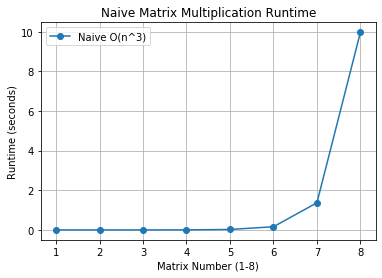

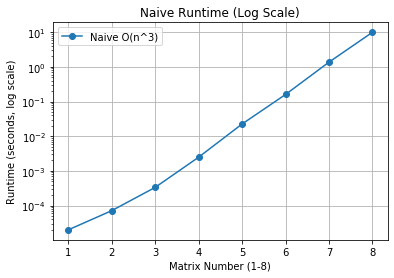

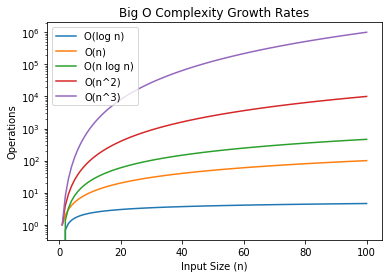

In [31]:
import time

def naive_matrix_multiplication(A, B):
    n = len(A)
    C = [[0] * n for _ in range(n)]
    for i in range(n):
        for j in range(n):
            for k in range(n):
                C[i][j] += A[i][k] * B[k][j]
    return C

# Matrix sizes
sizes = [3 * (2**i) for i in range(8)]
naive_times = []

# Run experiment
for size in sizes:
    print(f"Running size {size}...")
    A_np = np.random.rand(size, size)
    B_np = np.random.rand(size, size)
    A_list = A_np.tolist()
    B_list = B_np.tolist()

    start = time.time()
    naive_matrix_multiplication(A_list, B_list)
    naive_times.append(time.time() - start)

naive_times = np.array(naive_times, dtype=float)
sizes_array = np.arange(1, 9)

# Runtime plot
plt.figure()
plt.plot(sizes_array, naive_times, 'o-', label='Naive O(n^3)')
plt.xlabel("Matrix Number (1-8)")
plt.ylabel("Runtime (seconds)")
plt.title("Naive Matrix Multiplication Runtime")
plt.legend()
plt.grid(True)
plt.show()

# Log scale
plt.figure()
plt.plot(sizes_array, naive_times, 'o-', label='Naive O(n^3)')
plt.yscale('log')
plt.xlabel("Matrix Number (1-8)")
plt.ylabel("Runtime (seconds, log scale)")
plt.title("Naive Runtime (Log Scale)")
plt.legend()
plt.grid(True)
plt.show()

# Big O growth rates
n = np.linspace(1, 100, 100)
plt.plot(n, np.log(n), label='O(log n)')
plt.plot(n, n, label='O(n)')
plt.plot(n, n * np.log(n), label='O(n log n)')
plt.plot(n, n**2, label='O(n^2)')
plt.plot(n, n**3, label='O(n^3)')
plt.yscale('log')
plt.title('Big O Complexity Growth Rates')
plt.xlabel('Input Size (n)')
plt.ylabel('Operations')
plt.legend()
plt.show()

## Conclusion 
**Re-cap of the methods in assessing economics**

The cubic spline performed best for interpolation. It passes exactly through every data point and produces a smooth curve between known quarters. The key limitation of the spline is its sensitivity to outliers; one extreme value corrupts the estimates for surrounding quarters. As seen in the Big-O analysis above, it also provides a cheaper solution than it's peers. 

The degree-4 polynomial and linear regression performed best for trend analysis. It smoothed over the COVID shock rather than being forced through it, giving a more interpretable picture of long-run GDP behavior. The key limitation of the polynomial is that it sacrifices exactness at individual points and becomes numerically unstable at higher degrees. It also costs more as the matrix number increases, as expressed in the Big-O graph above. 

Linear regression is the simplest and most interpretable but assumes a constant trend with no cycles, which does not work when interpolatiing economic data. All of the methods have their own strength and weaknesses, and their applications can all be useful when catered to the task at hand. 

**Potential Next Steps**

Using the code we have developed above, we could try and apply these methods to other economic indicators like unemployment or inflation. This would test how well each algorithm generalizes beyond GDP, and could provide meaningful benchmarks for other long-term trends. 

Thank you for reading! 